# 02 - Preprocesado (pipeline fit/transform)

**Objetivo:** construir el pipeline de preprocesado (imputacion, tratamiento de outliers, encoding/escalado) como un artefacto `fit`/`transform` serializable, ajustado UNA sola vez sobre el train-split y aplicado de forma identica a train, test y produccion, sin fuga de datos.

**Entregables (contrato no negociable):**
- `data/processed/train.parquet` - 12 features + target (`SeriousDlqin2yrs`).
- `data/processed/test.parquet` - 12 features + target.
- `data/processed/produccion.parquet` - 45000 filas, target all-NaN, columna `id_fila_original`.
- `results/models/preprocessing_pipeline.joblib` - instancia `PreprocesadorCredito` fiteada (`escalar=True, recalcular_debtratio=True, winsorizar=True`).

La logica vive en `src/preprocessing.py`; este notebook la ORQUESTA y JUSTIFICA cada decision con numeros reales calculados sobre el train-split.

## Conectores

**Que recibe de los notebooks anteriores:**
- `data/cs_construccion.csv` (105000 x 11, target poblado) -> se divide en train/test.
- `data/cs_produccion.csv` (45000 x 11, target 100% NaN) -> se le crea `id_fila_original` = 0..44999.
- `results/tables/eda_resumen.csv` (especificacion por variable del 01_EDA).

**Que entrega a 03-07:** los 3 parquet + el joblib. Contrato de salida: 12 features (10 float64 + 2 flags int8); train/test = 13 columnas (+target), produccion = 14 (+target all-NaN + `id_fila_original`).

**Nota de rutas:** este notebook se ejecuta con `cwd = raiz del repo`, por lo que todas las rutas son `data/...`, `results/...` SIN `../` (a diferencia del 01_EDA, que corria desde `notebooks/`). Figuras y tablas de este notebook llevan prefijo `prep_`.

## Decisiones que afectan a este notebook

Este notebook CIERRA las cinco decisiones del bloque 1 (preprocesado), registradas como **D-1.1..D-1.5** en `docs/DECISIONES.md`.

- **D-1.1** (cierra en Hallazgo 2.2) - Imputacion: `MonthlyIncome` por mediana de tramo de edad + flag `is_missing_monthlyincome`; `NumberOfDependents` = moda (0) sin flag; PastDue 96/98 -> mediana(0) + flag `es_centinela_pastdue`.
- **D-1.2** (cierra en Hallazgos 3.1 y 3.2) - Outliers: recalculo de `DebtRatio` en filas `income_no_usable` (hipotesis de contaminacion CONFIRMADA) + winsor por columna (Revolving p99, DebtRatio p99.9).
- **D-1.3** (cierra en Hallazgo 3.2) - `age==0` tratado como missing e imputado con la mediana de train.
- **D-1.4** (cierra en Hallazgo 1.1) - Split: `train_test_split(test_size=0.2, stratify=target, random_state=42)`.
- **D-1.5** (cierra en Hallazgo 4.1) - Escalado: log1p en {DebtRatio, MonthlyIncome, RevolvingUtilization} (NO age) + StandardScaler; flag `escalar`; artefacto serializado con `escalar=True`.

Siguen ABIERTAS D-0.1, D-0.2, D-0.3 (supervisado vs bandit / un modelo con dos umbrales vs dos modelos / familia de modelo), que cierran 03/04.

In [1]:
# === Configuracion y estilo compartido (Taller B4-T2 XAI) - notebook 02 ===
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import joblib
from scipy.stats import ks_2samp, skew, chi2_contingency, spearmanr, pearsonr
from sklearn.metrics import roc_auc_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# cwd = raiz del repo -> rutas SIN "../". nbconvert lanza el kernel en el dir del
# notebook: si estamos en notebooks/, subimos a la raiz para cumplir el contrato.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
import src.preprocessing as prep
from src.preprocessing import (
    PreprocesadorCredito,
    construir_preprocesador,
    dividir_train_test,
)

RANDOM_STATE = 42
TARGET = PreprocesadorCredito.TARGET
FEATURES = PreprocesadorCredito.COLUMNAS_FEATURES
FLAGS = PreprocesadorCredito.FLAGS
COLS_PASTDUE = PreprocesadorCredito.COLS_PASTDUE
COLS_LOG = PreprocesadorCredito.COLS_LOG
COLS_WINSOR = PreprocesadorCredito.COLS_WINSOR
WINSOR_QUANTILES = PreprocesadorCredito.WINSOR_QUANTILES
BINS_EDAD = PreprocesadorCredito.BINS_EDAD
VALORES_CENTINELA = PreprocesadorCredito.VALORES_CENTINELA
UMBRAL_INCOME_NO_USABLE = PreprocesadorCredito.UMBRAL_INCOME_NO_USABLE

# --- Paleta y helpers reutilizados del 01_EDA (celda 3), rutas SIN "../" ---
COLOR_TARGET = {0: "#2a78d6", 1: "#e34948"}
COLOR_INK_PRIMARY = "#0b0b0b"
COLOR_INK_SECONDARY = "#52514e"
COLOR_MUTED = "#898781"
COLOR_GRID = "#e1e0d9"
COLOR_BASELINE = "#c3c2b7"
CMAP_DIVERGING = LinearSegmentedColormap.from_list("taller_diverging", ["#1c5cab", "#f0efec", "#e34948"])
CMAP_SEQUENTIAL = "Blues"

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 130,
    "savefig.dpi": 130,
    "axes.edgecolor": COLOR_BASELINE,
    "axes.labelcolor": COLOR_INK_PRIMARY,
    "text.color": COLOR_INK_PRIMARY,
    "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED,
    "grid.color": COLOR_GRID,
    "axes.grid": True,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_style("white")

def guardar_figura(fig, nombre):
    """Guarda la figura en results/figures/{nombre}.png (prefijo prep_)."""
    fig.tight_layout()
    fig.savefig(f"results/figures/{nombre}.png", dpi=130, bbox_inches="tight")
    plt.show()

def guardar_tabla(obj, nombre):
    """Guarda la tabla en results/tables/{nombre}.csv (prefijo prep_)."""
    path = f"results/tables/{nombre}.csv"
    if isinstance(obj, pd.Series):
        obj.to_frame().to_csv(path)
    else:
        obj.to_csv(path, index=True)
    return path

# --- Carga de datos (cwd = raiz) ---
df_train_full = pd.read_csv("data/cs_construccion.csv")
df_prod = pd.read_csv("data/cs_produccion.csv").reset_index(drop=True)
# Salvaguarda id_fila_original (BLOQUEANTE): 0..44999, preserva el orden original de prod.
df_prod["id_fila_original"] = np.arange(len(df_prod), dtype="int64")
eda_resumen = pd.read_csv("results/tables/eda_resumen.csv", index_col=0)

print("construccion:", df_train_full.shape, "(105000 x 11)")
print("produccion  :", df_prod.drop(columns=["id_fila_original"]).shape,
      "(45000 x 11) + id_fila_original ->", df_prod.shape)
print("eda_resumen :", eda_resumen.shape)
print("Prefijos de artefactos: results/figures/prep_0N_*.png , results/tables/prep_0N_*.csv")


construccion: (105000, 11) (105000 x 11)
produccion  : (45000, 11) (45000 x 11) + id_fila_original -> (45000, 12)
eda_resumen : (11, 5)
Prefijos de artefactos: results/figures/prep_0N_*.png , results/tables/prep_0N_*.csv


## 1. Division train/test

**Objetivo:** separar `cs_construccion.csv` en train/test ANTES de cualquier paso que aprenda parametros: es la primera barrera contra la fuga de datos. El split es estratificado por el target para preservar el desbalance (~6.6838% de clase positiva) en ambas particiones y evitar que la clase rara quede infra-representada en test.

In [2]:
# 1. Split estratificado (D-1.4): PRIMERO, antes de aprender nada.
df_train, df_test = dividir_train_test(df_train_full, test_size=0.2, random_state=RANDOM_STATE)

n_train, n_test = len(df_train), len(df_test)
tasa_train = df_train[TARGET].mean()
tasa_test = df_test[TARGET].mean()
tasa_full = df_train_full[TARGET].mean()
pos_train = int(df_train[TARGET].sum())
pos_test = int(df_test[TARGET].sum())
dif_pp = abs(tasa_train - tasa_test) * 100

split_resumen = pd.DataFrame({
    "n_filas": [n_train, n_test, n_train + n_test],
    "n_positivos": [pos_train, pos_test, pos_train + pos_test],
    "n_negativos": [n_train - pos_train, n_test - pos_test,
                    (n_train - pos_train) + (n_test - pos_test)],
    "tasa_clase_1": [tasa_train, tasa_test, tasa_full],
}, index=["train", "test", "total"])

print(split_resumen.to_string())
print(f"\ndiferencia de tasa train vs test: {dif_pp:.6f} pp")
guardar_tabla(split_resumen, "prep_01_split_resumen")

# --- Fuga por duplicados repartidos entre splits (nan-aware, nota informativa para 03) ---
# Contamos filas de test cuyo registro COMPLETO (10 features + target, tratando NaN como
# valor comparable) aparece IDENTICO en train: una gemela real (mismo (X, y)) es la unica
# que aportaria optimismo al coste de test. Impacto ~0 (costes simetricos).
cols_gemela = FEATURES + [TARGET]
def _claves_nan_aware(dfX):
    return [tuple(None if (isinstance(v, float) and np.isnan(v)) else v for v in fila)
            for fila in dfX.to_numpy()]
set_train_claves = set(_claves_nan_aware(df_train[cols_gemela]))
n_test_gemela = sum(1 for k in _claves_nan_aware(df_test[cols_gemela]) if k in set_train_claves)
pct_test_gemela = n_test_gemela / n_test * 100
print(f"duplicados repartidos: {n_test_gemela} filas de test ({pct_test_gemela:.4f}%) "
      f"tienen gemela exacta (10 features + target, nan-aware) en train")


       n_filas  n_positivos  n_negativos  tasa_clase_1
train    84000         5614        78386      0.066833
test     21000         1404        19596      0.066857
total   105000         7018        97982      0.066838

diferencia de tasa train vs test: 0.002381 pp


duplicados repartidos: 107 filas de test (0.5095%) tienen gemela exacta (10 features + target, nan-aware) en train


**Hallazgo 1.1:** (cierra **D-1.4**) el split estratificado `train_test_split(test_size=0.2, stratify=target, random_state=42)` produce **84000** filas de train y **21000** de test. La tasa de clase positiva se conserva casi identica: **0.066833** (5614 positivos) en train y **0.066857** (1404 positivos) en test, a solo **0.0024 pp** del **0.066838** global. Sin estratificar, los ~1400 positivos de test podrian quedar infra-representados por azar. El split va PRIMERO por diseno: todos los parametros de imputacion, recalculo, winsor y escalado se aprenden SOLO sobre estas 84000 filas de train (la verificacion anti-fuga se cierra en Hallazgo 6.1).

## 2. Imputacion de nulos

**Objetivo:** imputar `MonthlyIncome` y `NumberOfDependents` y tratar los centinelas 96/98 de las 3 columnas PastDue, respetando una dependencia dura: `age` se limpia ANTES de imputar `MonthlyIncome`, porque income se imputa por la mediana de su TRAMO DE EDAD (si age esta sucia, el tramo sale mal). Se fija la politica de flags de missingness (MNAR): que se conserva y que se descarta. La mascara canonica es `income_no_usable = MonthlyIncome.isna() | (MonthlyIncome <= 1)`, la MISMA para el flag, la imputacion de income y el recalculo de DebtRatio.

In [3]:
# 2.1 Pre-limpieza determinista (no aprende parametros) + flags ANTES de imputar.
# Copia de trabajo del train-split para los diagnosticos (F1/F2/F3); el artefacto
# canonico lo produce src.preprocessing en la seccion 5. Mismas definiciones.
Xtr = df_train[FEATURES].copy().astype({c: "float64" for c in FEATURES})
ytr = df_train[TARGET].copy()
dr_crudo = Xtr["DebtRatio"].copy()  # DebtRatio original, para validar la hipotesis

# --- Flags capturados del dato CRUDO, antes de imputar ---
income = Xtr["MonthlyIncome"]
income_no_usable = income.isna() | (income <= UMBRAL_INCOME_NO_USABLE)
flag_income = income_no_usable.astype("int8")

mask_centinela = pd.Series(False, index=Xtr.index)
for col in COLS_PASTDUE:
    mask_centinela = mask_centinela | Xtr[col].isin(VALORES_CENTINELA)
flag_centinela = mask_centinela.astype("int8")

# --- Conteos deterministas ---
n_nulos_income = int(income.isna().sum())
n_income_leq1 = int((income <= UMBRAL_INCOME_NO_USABLE).sum())
n_no_usable = int(income_no_usable.sum())
n_income_eq0 = int((income == 0).sum())
n_income_eq1 = int((income == 1).sum())
n_centinela = int(mask_centinela.sum())
n_age_cero = int((Xtr["age"] == 0).sum())
n_age_nan = int(Xtr["age"].isna().sum())

# --- Marcado determinista de missing (age==0 y 96/98 -> NaN) ---
Xtr.loc[(Xtr["age"] == 0) | Xtr["age"].isna(), "age"] = np.nan
for col in COLS_PASTDUE:
    Xtr.loc[Xtr[col].isin(VALORES_CENTINELA), col] = np.nan

# --- Tasas de target por grupo (validan la politica MNAR de flags, Hallazgo 2.1) ---
tasa_target_null = float(ytr[income.isna()].mean() * 100)
tasa_target_leq1 = float(ytr[(income <= UMBRAL_INCOME_NO_USABLE) & (~income.isna())].mean() * 100)
tasa_target_gt1 = float(ytr[income > UMBRAL_INCOME_NO_USABLE].mean() * 100)
tasa_target_centinela = float(ytr[mask_centinela].mean() * 100)
tasa_target_no_centinela = float(ytr[~mask_centinela].mean() * 100)

# chi2: income<=1 NO es estadisticamente identico a null (aunque comparten MECANISMO).
# La fusion del flag se justifica por procedencia (mismo numerador corrupto), no por tasa.
grupo_null = ytr[income.isna()]
grupo_leq1 = ytr[(income <= UMBRAL_INCOME_NO_USABLE) & (~income.isna())]
tabla_chi2 = np.array([[int((grupo_leq1 == 1).sum()), int((grupo_leq1 == 0).sum())],
                       [int((grupo_null == 1).sum()), int((grupo_null == 0).sum())]])
# Yates (correction=True, estandar en 2x2) -> chi2~6.87, p~0.0088.
chi2_leq1_null, p_leq1_null, _, _ = chi2_contingency(tabla_chi2, correction=True)

print(f"income_no_usable            : {n_no_usable} filas "
      f"({income_no_usable.mean()*100:.4f}%) = {n_nulos_income} nulos + "
      f"{n_income_leq1} con income<=1 ({n_income_eq0} con 0.0, {n_income_eq1} con 1.0)")
print(f"es_centinela_pastdue (96/98): {n_centinela} filas ({mask_centinela.mean()*100:.4f}%)")
print(f"age == 0                    : {n_age_cero} fila(s); age NaN: {n_age_nan}")
print(f"\ntasa target (train)  | income nulo: {tasa_target_null:.4f}%  "
      f"income<=1: {tasa_target_leq1:.4f}%  income>1: {tasa_target_gt1:.4f}%")
print(f"tasa target (train)  | centinela: {tasa_target_centinela:.4f}%  "
      f"no-centinela: {tasa_target_no_centinela:.4f}%")
print(f"\nchi2 income<=1 vs null (sobre target): chi2={chi2_leq1_null:.4f} "
      f"p={p_leq1_null:.6f} -> distintos entre si, misma direccion MNAR (fusion por MECANISMO)")

# --- 2.2 Aprender parametros de imputacion SOLO en train (nunca sobre test/prod: evita fuga). ---
# mediana de age (sobre age>0), medianas de income por tramo (EXCLUYENDO
# income_no_usable), mediana income global (income>1), moda dependents, mediana PastDue.
mediana_age = float(df_train.loc[df_train["age"] > 0, "age"].median())
Xtr.loc[Xtr["age"].isna(), "age"] = mediana_age  # age limpia ANTES de imputar income (income va por tramo de edad)

medianas_pastdue = {col: 0.0 for col in COLS_PASTDUE}  # mediana tras retirar 96/98 = 0
for col in COLS_PASTDUE:
    medianas_pastdue[col] = float(Xtr[col].median())  # ya sin centinela (son NaN)
    Xtr[col] = Xtr[col].fillna(medianas_pastdue[col])

# income por tramo, aprendido SOLO sobre usables (income>1) -> excluye income_no_usable
etiquetas_tramo = ["<=30", "31-40", "41-50", "51-60", "61-70", ">70"]
usables = ~income_no_usable
codigos_usables = pd.cut(Xtr.loc[usables, "age"], bins=BINS_EDAD).cat.codes
medianas_tramo_serie = Xtr.loc[usables, "MonthlyIncome"].groupby(
    codigos_usables, observed=False).median()
medianas_income_por_tramo = {int(k): float(v) for k, v in medianas_tramo_serie.items()}
mediana_income_global = float(Xtr.loc[usables, "MonthlyIncome"].median())

# Aplicar imputacion de income por tramo en las filas income_no_usable
n_bins = len(BINS_EDAD) - 1
lut = np.array([medianas_income_por_tramo.get(i, mediana_income_global)
                for i in range(n_bins)], dtype="float64")
codigos_all = pd.cut(Xtr["age"], bins=BINS_EDAD).cat.codes.to_numpy()
Xtr.loc[income_no_usable, "MonthlyIncome"] = lut[codigos_all][income_no_usable.to_numpy()]

# dependents: moda global (0), sin flag
moda_dependents = float(Xtr["NumberOfDependents"].mode(dropna=True).iloc[0])
Xtr["NumberOfDependents"] = Xtr["NumberOfDependents"].fillna(moda_dependents)

# Tabla de parametros aprendidos
filas_param = [{"parametro": "mediana_age", "valor": mediana_age}]
for i, et in enumerate(etiquetas_tramo):
    filas_param.append({"parametro": f"mediana_income_tramo_{et}",
                        "valor": medianas_income_por_tramo.get(i, np.nan)})
filas_param.append({"parametro": "mediana_income_global", "valor": mediana_income_global})
filas_param.append({"parametro": "moda_dependents", "valor": moda_dependents})
for col in COLS_PASTDUE:
    filas_param.append({"parametro": f"mediana_pastdue_{col}", "valor": medianas_pastdue[col]})
tabla_param = pd.DataFrame(filas_param).set_index("parametro")

print(tabla_param.to_string())
guardar_tabla(tabla_param, "prep_02_imputacion_parametros")


income_no_usable            : 17900 filas (21.3095%) = 16695 nulos + 1205 con income<=1 (866 con 0.0, 339 con 1.0)
es_centinela_pastdue (96/98): 149 filas (0.1774%)
age == 0                    : 1 fila(s); age NaN: 0

tasa target (train)  | income nulo: 5.6484%  income<=1: 3.8174%  income>1: 6.9970%
tasa target (train)  | centinela: 53.6913%  no-centinela: 6.5998%

chi2 income<=1 vs null (sobre target): chi2=6.8716 p=0.008758 -> distintos entre si, misma direccion MNAR (fusion por MECANISMO)
                                                       valor
parametro                                                   
mediana_age                                             52.0
mediana_income_tramo_<=30                             2959.0
mediana_income_tramo_31-40                            5000.0
mediana_income_tramo_41-50                            6167.0
mediana_income_tramo_51-60                            6400.0
mediana_income_tramo_61-70                            5907.5
mediana_income_

'results/tables/prep_02_imputacion_parametros.csv'

**Hallazgo 2.1:** parametros de imputacion aprendidos SOLO en train (84000 filas). La politica completa vive en las Decisiones (D-1.1); aqui van los numeros y por que se conserva cada flag.

**Parametros aprendidos:**
- `age`: mediana **52.0000** (sobre age>0).
- `MonthlyIncome` por tramo de edad (EXCLUYENDO `income_no_usable`): {<=30: **2959.0**, 31-40: **5000.0**, 41-50: **6167.0**, 51-60: **6400.0**, 61-70: **5907.5**, >70: **4526.0**}; fallback global **5460.0**.
- `NumberOfDependents`: moda **0**. Las 3 PastDue tras retirar centinelas: mediana **0**.

**Que flag se conserva y por que:**
- `is_missing_monthlyincome` = `income_no_usable` (isna | income<=1) = **17900** filas (**21.3095%**): 16695 nulos + 1205 con income<=1 (866 con 0.0, 339 con 1.0). Se conserva: el EDA ya probo que su patron MNAR sobrevive al controlar por edad (logit p=**0.012248**, OR 0.9150). Las tasas de target lo confirman: income<=1 **3.8174%**, nulos **5.6484%**, income>1 **6.9970%**.
- `es_centinela_pastdue` = **149** filas en train. Se conserva: dispara la tasa de target a **53.6913%** frente a **6.5998%** en el resto (~8x).
- `NumberOfDependents`: se DESCARTA el flag. Deja de ser significativo al controlar por edad (el EDA lo midio, p=**0.114677**) y sus nulos son subconjunto exacto de los de MonthlyIncome.

**Fusion por MECANISMO, no por tasa (honestidad):** income<=1 NO es estadisticamente identico a null (chi2 sobre target = **6.8716**, p=**0.008758**; income<=1 defaultea aun menos, 3.8174% vs 5.6484%). Pero comparte el MECANISMO con los nulos: mismo numerador de `DebtRatio` corrupto, misma mascara de recalculo, misma imputacion por tramo. El flag marca "ingreso no reconstruible desde el origen", no literalmente "ausente". El nombre `is_missing_monthlyincome` es una etiqueta de conveniencia (se conserva por contrato con 03-07); su definicion exacta es `MonthlyIncome.isna() OR MonthlyIncome <= 1`.

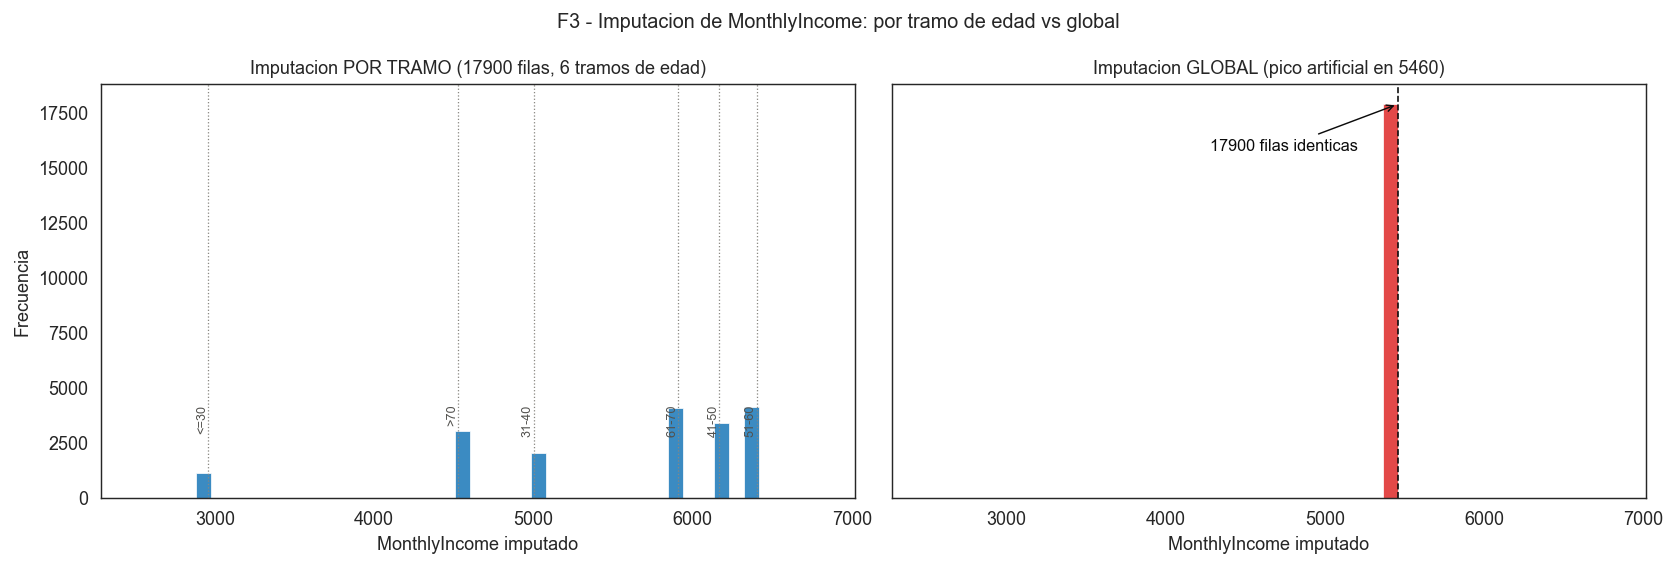

gradiente por tramo: {'<=30': 2959.0, '31-40': 5000.0, '41-50': 6167.0, '51-60': 6400.0, '61-70': 5907.5, '>70': 4526.0}


In [4]:
# 2.3 F3: comparar imputacion por tramo vs global sobre las filas income_no_usable.
# por-tramo reparte la masa segun el gradiente de edad; global inyecta un pico en 5460.
imp_por_tramo = lut[codigos_all][income_no_usable.to_numpy()]
imp_global = np.full(n_no_usable, mediana_income_global)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
bins = np.linspace(2500, 6800, 46)
axes[0].hist(imp_por_tramo, bins=bins, color=plt.get_cmap(CMAP_SEQUENTIAL)(0.65),
             edgecolor="white", linewidth=0.4)
axes[0].set_title(f"Imputacion POR TRAMO ({n_no_usable} filas, 6 tramos de edad)", fontsize=10)
axes[0].set_xlabel("MonthlyIncome imputado")
axes[0].set_ylabel("Frecuencia")
ymax0 = axes[0].get_ylim()[1]
for et, i in zip(etiquetas_tramo, range(n_bins)):
    v = medianas_income_por_tramo.get(i, mediana_income_global)
    axes[0].axvline(v, color=COLOR_MUTED, linestyle=":", linewidth=0.7)
    axes[0].text(v, ymax0 * 0.98, et, rotation=90, ha="right", va="top",
                 fontsize=7, color=COLOR_INK_SECONDARY)

axes[1].hist(imp_global, bins=bins, color=COLOR_TARGET[1],
             edgecolor="white", linewidth=0.4)
axes[1].set_title(f"Imputacion GLOBAL (pico artificial en {mediana_income_global:.0f})", fontsize=10)
axes[1].set_xlabel("MonthlyIncome imputado")
axes[1].axvline(mediana_income_global, color=COLOR_INK_PRIMARY, linestyle="--", linewidth=0.9)
axes[1].annotate(f"{n_no_usable} filas identicas", xy=(mediana_income_global, n_no_usable),
                 xytext=(mediana_income_global - 250, n_no_usable * 0.88),
                 ha="right", fontsize=9, color=COLOR_INK_PRIMARY,
                 arrowprops=dict(arrowstyle="->", color=COLOR_INK_PRIMARY, lw=0.8))

fig.suptitle("F3 - Imputacion de MonthlyIncome: por tramo de edad vs global", fontsize=11)
guardar_figura(fig, "prep_03_imputacion_income_tramo_vs_global")
print("gradiente por tramo:", {et: medianas_income_por_tramo.get(i, mediana_income_global)
                                for i, et in enumerate(etiquetas_tramo)})


**Hallazgo 2.2:** (cierra **D-1.1**) la imputacion por tramo de edad bate a la global. La global colapsaria las **17900** filas `income_no_usable` a un unico valor (**5460.0**): un pico artificial (panel derecho de F3) que aplana el gradiente real de ingreso por edad. La imputacion por tramo (panel izquierdo) preserva ese gradiente en forma de U invertida: sube de **2959.0** (<=30) hasta **6400.0** (51-60) y luego baja a **4526.0** (>70). Requiere `age` ya limpia (Hallazgo 2.1). Con esto queda fijada la politica D-1.1 detallada en las Decisiones.

## 3. Tratamiento de outliers

**Objetivo:** los centinelas 96/98 ya se marcaron en 2.1; aqui va la aportacion analitica de mas valor (50% de la nota): VALIDAR la hipotesis del `DebtRatio` contaminado (el CSV guarda el numerador crudo -los pagos- cuando falta el ingreso, no el ratio). En vez de winsorizar a ciegas la cola extrema (**~2100** filas con `DebtRatio`>p97.5), recalculamos `DebtRatio` con el ingreso imputado en las **17900** filas `income_no_usable`, y solo despues winsorizamos el residuo por columna (Revolving p99, DebtRatio p99.9). Ademas se comprueba (3.4) que el tratamiento de centinelas colapsa el VIF severo de las 3 PastDue que el 01_EDA dejo abierto.

In [5]:
# 3.1 Validar la hipotesis: DebtRatio de las filas income_no_usable es el numerador crudo.
dr_no_usable_antes = dr_crudo.loc[income_no_usable].dropna()
dr_usable = dr_crudo.loc[usables].dropna()
mediana_dr_no_usable_antes = float(dr_no_usable_antes.median())
mediana_dr_usable = float(dr_usable.median())
ratio_medianas = mediana_dr_no_usable_antes / mediana_dr_usable

# La cola DebtRatio > p97.5: que fraccion es income_no_usable?
p975_dr = float(dr_crudo.quantile(0.975))
mask_cola = dr_crudo > p975_dr
n_cola = int(mask_cola.sum())
pct_cola_no_usable = float(income_no_usable[mask_cola].mean() * 100)

tabla_dr = pd.DataFrame({
    "metrica": ["n_income_no_usable", "mediana_DebtRatio_no_usable_ANTES",
                "mediana_DebtRatio_usable", "ratio_medianas",
                "umbral_p97.5_DebtRatio", "n_cola_>p97.5",
                "pct_cola_que_es_income_no_usable"],
    "valor": [n_no_usable, mediana_dr_no_usable_antes, mediana_dr_usable,
              ratio_medianas, p975_dr, n_cola, pct_cola_no_usable],
}).set_index("metrica")

print(tabla_dr.to_string())
print(f"\n-> mediana DebtRatio no-usable = {mediana_dr_no_usable_antes:.4f} vs "
      f"usable = {mediana_dr_usable:.6f} (ratio {ratio_medianas:.1f}x)")
print(f"-> {pct_cola_no_usable:.4f}% de las {n_cola} filas con DebtRatio>p97.5 "
      f"son income_no_usable")

# Referencia cruzada con la especificacion del 01_EDA (eda_resumen): ya senalaba el artefacto.
_eda_dr = eda_resumen.set_index("variable").loc["DebtRatio"]
print(f"\n[01_EDA] recomendaba para DebtRatio: {_eda_dr['transformacion_recomendada']}")
print(f"[01_EDA] nota: {_eda_dr['notas']}")
guardar_tabla(tabla_dr, "prep_03_debtratio_recalculo")


                                          valor
metrica                                        
n_income_no_usable                 17900.000000
mediana_DebtRatio_no_usable_ANTES   1152.000000
mediana_DebtRatio_usable               0.290216
ratio_medianas                      3969.463100
umbral_p97.5_DebtRatio              3538.025000
n_cola_>p97.5                       2100.000000
pct_cola_que_es_income_no_usable     100.000000

-> mediana DebtRatio no-usable = 1152.0000 vs usable = 0.290216 (ratio 3969.5x)
-> 100.0000% de las 2100 filas con DebtRatio>p97.5 son income_no_usable

[01_EDA] recomendaba para DebtRatio: Tratar cola > p97.5 junto con la imputacion de MonthlyIncome + log1p + StandardScaler
[01_EDA] nota: 2625 filas (2.5000%) con DebtRatio > p97.5 (3510.0250), 95.1619% de ellas con MonthlyIncome nulo (Hallazgo 3.3); posible artefacto de division por ingreso nulo/casi 0.


'results/tables/prep_03_debtratio_recalculo.csv'

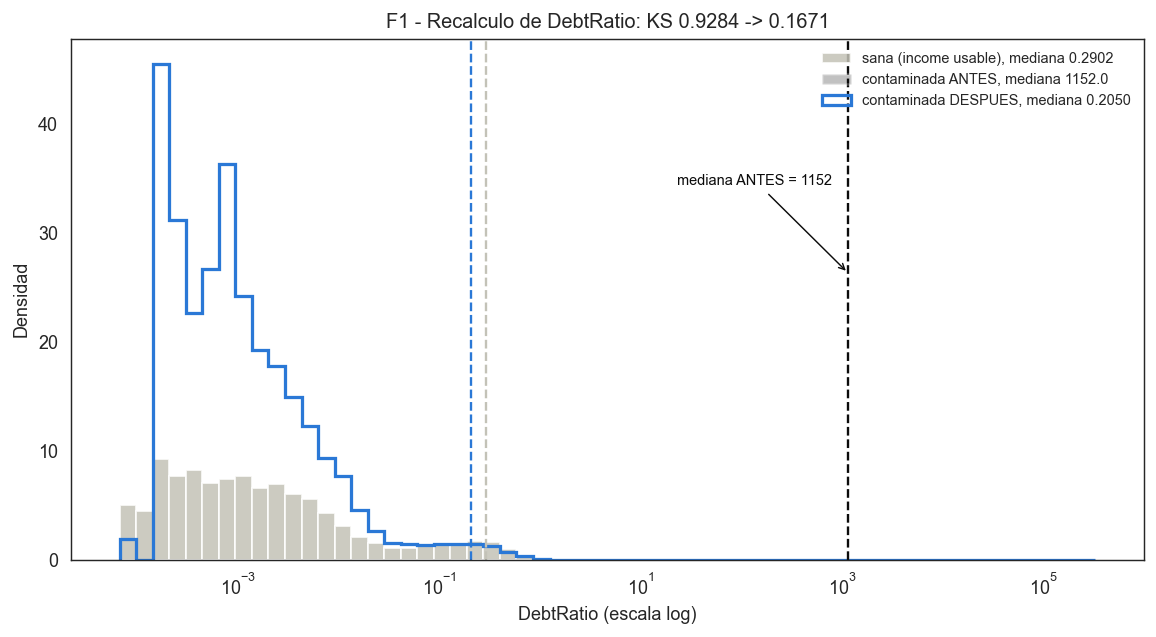

KS 0.928403 -> 0.167121 ; mediana 1152.0 -> 0.204997 (sana 0.290216)
AUC univariante DebtRatio->target: crudo 0.5212 -> recalc 0.5531  (la senal MEJORA, no se destruye)
acoplamiento age  | Spearman(DR,age): +0.0289 -> -0.0981 ; Pearson(DR,age) despues -0.0059 (despreciable)
con income NO se crea correlacion | Spearman(DR,income): -0.0386 -> -0.0386


In [6]:
# 3.2 Aplicar el recalculo: DebtRatio := DebtRatio_crudo / MonthlyIncome_imputado
# en las filas income_no_usable (income ya imputado >> 1, nunca /0). Actualiza Xtr.
income_imputado = Xtr["MonthlyIncome"]  # ya imputado en 2.2
Xtr.loc[income_no_usable, "DebtRatio"] = (
    dr_crudo.loc[income_no_usable] / income_imputado.loc[income_no_usable])
dr_no_usable_despues = Xtr["DebtRatio"].loc[income_no_usable].dropna()
mediana_dr_no_usable_despues = float(dr_no_usable_despues.median())

# KS de dos muestras (contaminada vs sana), antes y despues del recalculo.
ks_antes = float(ks_2samp(dr_no_usable_antes, dr_usable).statistic)
ks_despues = float(ks_2samp(dr_no_usable_despues, dr_usable).statistic)

# PRO del recalculo: no solo normaliza la forma, MEJORA la senal predictiva (AUC univariante).
dr_debtratio_recalc = Xtr["DebtRatio"]  # ya recalculado en las filas income_no_usable
auc_debtratio_crudo = float(roc_auc_score(ytr, dr_crudo))
auc_debtratio_recalc = float(roc_auc_score(ytr, dr_debtratio_recalc))
# COSTE honesto: dividir por la mediana de income del TRAMO DE EDAD inyecta un acoplamiento
# debil DebtRatio<-age (con income NO se crea correlacion artificial).
sp_dr_age_antes = float(spearmanr(dr_crudo, Xtr["age"]).statistic)
sp_dr_age_despues = float(spearmanr(dr_debtratio_recalc, Xtr["age"]).statistic)
pe_dr_age_despues = float(pearsonr(dr_debtratio_recalc, Xtr["age"]).statistic)
sp_dr_income_antes = float(spearmanr(dr_crudo, income_imputado).statistic)
sp_dr_income_despues = float(spearmanr(dr_debtratio_recalc, income_imputado).statistic)

# F1: KDE/hist en eje x-log de DebtRatio (sana / contaminada antes / despues).
fig, ax = plt.subplots(figsize=(9, 5))
def _pos(s):
    a = s.to_numpy(); return a[a > 0]
sana = _pos(dr_usable)
antes = _pos(dr_no_usable_antes)
despues = _pos(dr_no_usable_despues)
lo = min(sana.min(), antes.min(), despues.min())
hi = max(sana.max(), antes.max(), despues.max())
log_bins = np.logspace(np.log10(lo), np.log10(hi), 60)
ax.hist(sana, bins=log_bins, density=True, color=COLOR_BASELINE, alpha=0.85,
        label=f"sana (income usable), mediana {mediana_dr_usable:.4f}")
# ANTES como area rellena (alpha bajo) para que la masa a la derecha no sea invisible.
ax.hist(antes, bins=log_bins, density=True, histtype="stepfilled", alpha=0.25,
        linewidth=1.4, color=COLOR_INK_PRIMARY,
        label=f"contaminada ANTES, mediana {mediana_dr_no_usable_antes:.1f}")
ax.hist(despues, bins=log_bins, density=True, histtype="step", linewidth=1.8,
        color=COLOR_TARGET[0],
        label=f"contaminada DESPUES, mediana {mediana_dr_no_usable_despues:.4f}")
# Lineas verticales de mediana (color de cada serie): el desplazamiento se ve de un vistazo.
ymax = ax.get_ylim()[1]
ax.axvline(mediana_dr_usable, color=COLOR_BASELINE, linestyle="--", linewidth=1.3)
ax.axvline(mediana_dr_no_usable_antes, color=COLOR_INK_PRIMARY, linestyle="--", linewidth=1.3)
ax.axvline(mediana_dr_no_usable_despues, color=COLOR_TARGET[0], linestyle="--", linewidth=1.3)
ax.annotate(f"mediana ANTES = {mediana_dr_no_usable_antes:.0f}",
            xy=(mediana_dr_no_usable_antes, ymax * 0.55),
            xytext=(mediana_dr_no_usable_antes * 0.02, ymax * 0.72),
            fontsize=8, color=COLOR_INK_PRIMARY,
            arrowprops=dict(arrowstyle="->", color=COLOR_INK_PRIMARY, lw=0.8))
ax.set_xscale("log")
ax.set_xlabel("DebtRatio (escala log)")
ax.set_ylabel("Densidad")
ax.set_title(f"F1 - Recalculo de DebtRatio: KS {ks_antes:.4f} -> {ks_despues:.4f}", fontsize=11)
ax.legend(fontsize=8, frameon=False)
guardar_figura(fig, "prep_01_debtratio_recalculo_validacion")

# Actualizar la tabla con las estadisticas DESPUES.
tabla_dr_final = pd.concat([tabla_dr, pd.DataFrame({
    "metrica": ["mediana_DebtRatio_no_usable_DESPUES", "ks_antes", "ks_despues",
                "n_filas_recalculadas"],
    "valor": [mediana_dr_no_usable_despues, ks_antes, ks_despues, n_no_usable],
}).set_index("metrica")])
guardar_tabla(tabla_dr_final, "prep_03_debtratio_recalculo")
print(f"KS {ks_antes:.6f} -> {ks_despues:.6f} ; mediana {mediana_dr_no_usable_antes:.1f} -> "
      f"{mediana_dr_no_usable_despues:.6f} (sana {mediana_dr_usable:.6f})")
print(f"AUC univariante DebtRatio->target: crudo {auc_debtratio_crudo:.4f} -> "
      f"recalc {auc_debtratio_recalc:.4f}  (la senal MEJORA, no se destruye)")
print(f"acoplamiento age  | Spearman(DR,age): {sp_dr_age_antes:+.4f} -> {sp_dr_age_despues:+.4f} ; "
      f"Pearson(DR,age) despues {pe_dr_age_despues:+.4f} (despreciable)")
print(f"con income NO se crea correlacion | Spearman(DR,income): {sp_dr_income_antes:+.4f} -> "
      f"{sp_dr_income_despues:+.4f}")


**Hallazgo 3.1:** (cierra parte de **D-1.2**) hipotesis del `DebtRatio` contaminado **CONFIRMADA** sobre train.

**La evidencia.** En las **17900** filas `income_no_usable`, la mediana de `DebtRatio` crudo es **1152.0000** frente a **0.290216** en las usables: un ratio de ~**3970x**. Ademas, el **100.0000%** de la cola `DebtRatio`>p97.5 (**2100** filas, umbral **3538.0250**) es `income_no_usable`. Diagnostico: el CSV guardaba el numerador (los pagos), no el ratio.

**El arreglo.** Recalculamos `DebtRatio := DebtRatio_crudo / MonthlyIncome_imputado` en esas filas. El KS de dos muestras (contaminada vs sana) cae de **0.928403** a **0.167121** y la mediana pasa de **1152.0000** a **0.204997**, solapandose con la sana (**0.290216**) -como muestra F1. Es un diagnostico falsable: se rechazaria si el KS no bajase. Y distingue dos magnitudes: winsorizar a ciegas habria aplastado solo las **~2100** filas de la cola; recalcular corrige las **17900** sin tirar informacion.

**El recalculo MEJORA la senal, no la destruye.** El AUC univariante `DebtRatio` -> target sube de **0.5212** (crudo) a **0.5531** (recalculado). Alinea `DebtRatio` con el sentido de un ratio de deuda, en vez de mezclarlo con la senal de missingness (que ya vive en el flag).

**Coste declarado (honestidad).** Dividir por la mediana de income del **tramo de edad** inyecta un acoplamiento DEBIL `DebtRatio`<-`age` (Spearman **+0.0289 -> -0.0981**; Pearson **-0.0059**, despreciable). Respecto a income NO se crea correlacion artificial (Spearman **-0.0386 -> -0.0386**, sin cambio). Es real pero debil y trazable: `age` es su propia feature y el flag `is_missing_monthlyincome` marca exactamente las filas afectadas.

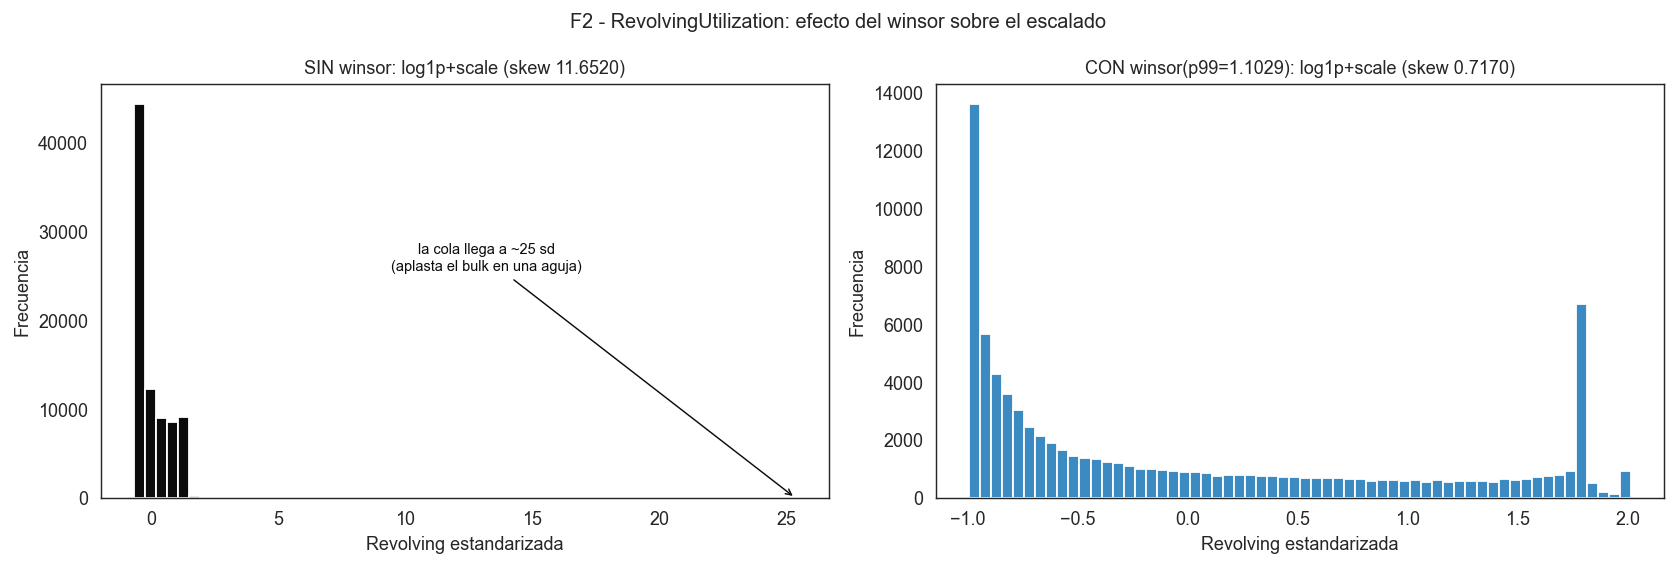

                                      cuantil_cap  lower  cap_upper  skew_crudo  skew_log1p_solo  skew_winsor_p99_log1p  skew_winsor_p99.9_log1p
columna                                                                                                                                         
RevolvingUtilizationOfUnsecuredLines        0.990    0.0   1.102904   63.096842        11.652033               0.717035                10.127196
DebtRatio                                   0.999    0.0   9.184215         NaN              NaN                    NaN                      NaN

cap Revolving (p99) = 1.102904 ; cap DebtRatio (p99.9) = 9.184215
cap Revolving p99.9 (alternativa descartada) = 1549.014000 -> apenas ayuda al skew
Revolving skew: crudo 63.0968 | log1p solo 11.6520 | winsor p99+log1p 0.7170 | winsor p99.9+log1p 10.1272


'results/tables/prep_04_winsor_bounds.csv'

In [7]:
# 3.3 Winsorizar el residuo por columna (caps aprendidos en train, tras recalculo).
limites_winsor = {}
for col in COLS_WINSOR:
    high = float(Xtr[col].quantile(WINSOR_QUANTILES[col]))
    limites_winsor[col] = (0.0, high)
cap_revolving = limites_winsor["RevolvingUtilizationOfUnsecuredLines"][1]
cap_debtratio = limites_winsor["DebtRatio"][1]

# Skews comparativos de Revolving bajo distintos caps (justifican p99, no p99.9).
rev = Xtr["RevolvingUtilizationOfUnsecuredLines"]
cap_rev_p999 = float(rev.quantile(0.999))
skew_rev_crudo = float(skew(rev.to_numpy()))
skew_rev_log1p_solo = float(skew(np.log1p(rev.to_numpy())))
skew_rev_winsor_p99_log1p = float(skew(np.log1p(rev.clip(0, cap_revolving).to_numpy())))
skew_rev_winsor_p999_log1p = float(skew(np.log1p(rev.clip(0, cap_rev_p999).to_numpy())))

# Aplicar winsor a Xtr (por columna).
for col in COLS_WINSOR:
    low, high = limites_winsor[col]
    Xtr[col] = Xtr[col].clip(lower=low, upper=high)

# F2: consecuencia downstream de NO capar Revolving (2 paneles).
rev_sin_winsor_std = (np.log1p(rev) - np.log1p(rev).mean()) / np.log1p(rev).std()
rev_con_winsor = rev.clip(0, cap_revolving)
rev_con_winsor_std = ((np.log1p(rev_con_winsor) - np.log1p(rev_con_winsor).mean())
                      / np.log1p(rev_con_winsor).std())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
max_std_sin = float(np.nanmax(rev_sin_winsor_std))
axes[0].hist(rev_sin_winsor_std, bins=60, color=COLOR_INK_PRIMARY)
axes[0].set_title(f"SIN winsor: log1p+scale (skew {skew_rev_log1p_solo:.4f})", fontsize=10)
axes[0].set_xlabel("Revolving estandarizada")
axes[0].set_ylabel("Frecuencia")
# Anotar la cola: sin winsor el outlier llega a ~25 sd y aplasta el bulk en una aguja.
axes[0].annotate(f"la cola llega a ~{max_std_sin:.0f} sd\n(aplasta el bulk en una aguja)",
                 xy=(max_std_sin, 0), xytext=(max_std_sin * 0.52, axes[0].get_ylim()[1] * 0.55),
                 ha="center", fontsize=8, color=COLOR_INK_PRIMARY,
                 arrowprops=dict(arrowstyle="->", color=COLOR_INK_PRIMARY, lw=0.8))
axes[1].hist(rev_con_winsor_std, bins=60, color=plt.get_cmap(CMAP_SEQUENTIAL)(0.65))
axes[1].set_title(f"CON winsor(p99={cap_revolving:.4f}): log1p+scale (skew {skew_rev_winsor_p99_log1p:.4f})",
                  fontsize=10)
axes[1].set_xlabel("Revolving estandarizada")
axes[1].set_ylabel("Frecuencia")
fig.suptitle("F2 - RevolvingUtilization: efecto del winsor sobre el escalado", fontsize=11)
guardar_figura(fig, "prep_02_revolving_winsor_efecto_escalado")

tabla_winsor = pd.DataFrame({
    "columna": COLS_WINSOR,
    "cuantil_cap": [WINSOR_QUANTILES[c] for c in COLS_WINSOR],
    "lower": [limites_winsor[c][0] for c in COLS_WINSOR],
    "cap_upper": [limites_winsor[c][1] for c in COLS_WINSOR],
}).set_index("columna")
tabla_winsor.loc["RevolvingUtilizationOfUnsecuredLines", "skew_crudo"] = skew_rev_crudo
tabla_winsor.loc["RevolvingUtilizationOfUnsecuredLines", "skew_log1p_solo"] = skew_rev_log1p_solo
tabla_winsor.loc["RevolvingUtilizationOfUnsecuredLines", "skew_winsor_p99_log1p"] = skew_rev_winsor_p99_log1p
tabla_winsor.loc["RevolvingUtilizationOfUnsecuredLines", "skew_winsor_p99.9_log1p"] = skew_rev_winsor_p999_log1p
print(tabla_winsor.to_string())
print(f"\ncap Revolving (p99) = {cap_revolving:.6f} ; cap DebtRatio (p99.9) = {cap_debtratio:.6f}")
print(f"cap Revolving p99.9 (alternativa descartada) = {cap_rev_p999:.6f} -> apenas ayuda al skew")
print(f"Revolving skew: crudo {skew_rev_crudo:.4f} | log1p solo {skew_rev_log1p_solo:.4f} | "
      f"winsor p99+log1p {skew_rev_winsor_p99_log1p:.4f} | winsor p99.9+log1p {skew_rev_winsor_p999_log1p:.4f}")
guardar_tabla(tabla_winsor, "prep_04_winsor_bounds")


In [8]:
# 3.4 El VIF severo de las 3 PastDue que detecto el 01_EDA era un ARTEFACTO de los
# centinelas 96/98: dos columnas que coinciden en las mismas ~150 filas con el valor 96/98
# aparentan Pearson ~0.99. Al reemplazar 96/98 por la mediana (0) esa colinealidad se
# desvanece. ANTES = features crudas (96/98 presentes; NaN de income/dependents y age==0 a
# mediana solo para poder calcular el VIF). DESPUES = features ya tratadas (centinela->0,
# imputacion, recalculo, winsor, log1p) = lo que ve un modelo lineal. statsmodels sobre train.
def _vif(dfX):
    Xc = add_constant(dfX.astype("float64"), has_constant="add")
    vals = Xc.to_numpy()
    return pd.Series({c: float(variance_inflation_factor(vals, i))
                      for i, c in enumerate(Xc.columns) if c != "const"})

X_vif_antes = df_train[FEATURES].copy().astype("float64")
for _c in ["MonthlyIncome", "NumberOfDependents"]:
    X_vif_antes[_c] = X_vif_antes[_c].fillna(X_vif_antes[_c].median())
X_vif_antes.loc[(X_vif_antes["age"] == 0) | X_vif_antes["age"].isna(), "age"] = \
    X_vif_antes["age"].median()

# DESPUES: Xtr ya trae centinela->0, imputacion, recalculo y winsor; solo falta el log1p
# (StandardScaler es afin -> no altera el VIF, se omite). NO age.
X_vif_despues = Xtr[FEATURES].copy()
for _c in COLS_LOG:
    X_vif_despues[_c] = np.log1p(X_vif_despues[_c])

vif_antes = _vif(X_vif_antes)
vif_despues = _vif(X_vif_despues)
vif_tab = pd.DataFrame({"VIF_antes": vif_antes, "VIF_despues": vif_despues}).loc[FEATURES]
guardar_tabla(vif_tab, "prep_07_vif_antes_despues")

# Multicolinealidad Pearson entre las 3 PastDue (el ~0.99 del 01), antes/despues.
iu = np.triu_indices(len(COLS_PASTDUE), k=1)
pear_antes_max = float(X_vif_antes[COLS_PASTDUE].corr().to_numpy()[iu].max())
pear_despues_max = float(Xtr[COLS_PASTDUE].corr().to_numpy()[iu].max())
vif_max_despues = float(vif_despues.max())

print(vif_tab.round(4).to_string())
print("\nVIF PastDue ANTES : " + ", ".join(f"{vif_antes[c]:.2f}" for c in COLS_PASTDUE))
print("VIF PastDue DESPUES: " + ", ".join(f"{vif_despues[c]:.2f}" for c in COLS_PASTDUE))
print(f"VIF maximo de TODAS las features DESPUES: {vif_max_despues:.4f}")
print(f"Pearson max entre las 3 PastDue: antes {pear_antes_max:.4f} -> despues {pear_despues_max:.4f}")


                                      VIF_antes  VIF_despues
RevolvingUtilizationOfUnsecuredLines     1.0006       1.2498
age                                      1.0844       1.1709
NumberOfTime30-59DaysPastDueNotWorse    40.8977       1.1781
DebtRatio                                1.0240       1.9065
MonthlyIncome                            1.0160       1.5578
NumberOfOpenCreditLinesAndLoans          1.2860       1.4221
NumberOfTimes90DaysLate                 71.6977       1.1494
NumberRealEstateLoansOrLines             1.2755       1.8750
NumberOfTime60-89DaysPastDueNotWorse    89.6394       1.1720
NumberOfDependents                       1.0787       1.1171

VIF PastDue ANTES : 40.90, 71.70, 89.64
VIF PastDue DESPUES: 1.18, 1.15, 1.17
VIF maximo de TODAS las features DESPUES: 1.9065
Pearson max entre las 3 PastDue: antes 0.9926 -> despues 0.2995


**Hallazgo 3.2:** (cierra **D-1.2** y **D-1.3**) caps de winsor aprendidos en train (`clip`, robusto a no-vistos): `RevolvingUtilizationOfUnsecuredLines` a p99 = **1.102904** y `DebtRatio` (ya recalculado) a p99.9 = **9.184215**, ambos con lower=0. El cap de Revolving es CRITICO: su skew crudo es **63.0968** y log1p a secas lo deja en **11.6520**; capar a p99.9 (=1549.014) apenas ayuda (skew log1p **10.1272**), mientras que capar a p99 (~1.10) antes de log1p lo reduce a **0.7170** (F2). El `clip` protege frente a valores no vistos de produccion (Revolving max **50708** -> cap 1.102904; Dependents max 20 vs train 10). Cierra **D-1.2** (recalculo + winsor por columna) y tambien **D-1.3** (`age==0`, **1** fila en el train-split): el marcado a NaN y la imputacion con la mediana **52.0000** se hicieron en la seccion 2; su cierre formal se anota aqui por ser tambien un outlier.

**Colapso del VIF (hallazgo que el 01 dejo abierto):** el tratamiento de centinelas RESUELVE la multicolinealidad severa que el EDA detecto. El VIF de las 3 PastDue cae de **40.90 / 71.70 / 89.64** (features crudas, con 96/98) a **1.18 / 1.15 / 1.17** tras reemplazar los centinelas por la mediana (0), y el Pearson entre ellas de **0.9926** a **0.2995**; el VIF maximo de TODAS las features queda en **1.9065** (`DebtRatio`), muy por debajo del umbral de multicolinealidad (5-10). El VIF **40.9/71.7/89.6** del 01 era un ARTEFACTO de las **149** filas centinela 96/98 (dos conteos que coinciden en esas mismas filas con el valor 96/98 aparentan Pearson ~0.99). **Consecuencia para el modelado (D-0.3):** los modelos lineales/bandit NO necesitan consolidar las 3 PastDue en un indice unico; entran como features separadas sin inflar la varianza de los coeficientes. Detalle en la tabla `prep_07_vif_antes_despues`.

## 4. Encoding y escalado

**Objetivo:** no hay variables categoricas, por lo que el "encoding" es trivial (los 2 flags ya son 0/1). El trabajo real es la normalizacion: log1p sobre las 3 variables muy sesgadas (`DebtRatio`, `MonthlyIncome`, `RevolvingUtilization`; NO `age`) + StandardScaler sobre las 10 features, todo condicionado por el flag `escalar` para servir tanto a modelos lineales/bandit (`escalar=True`) como a arboles (`escalar=False`).

In [9]:
# 4.1 Construir el pipeline canonico (src.preprocessing) con los defaults decididos.
pipe = construir_preprocesador(escalar=True, recalcular_debtratio=True, winsorizar=True)
print("pipeline:", pipe)

# Skews finales (StandardScaler es lineal -> preserva el skew) de una prueba de fit.
_pipe_probe = construir_preprocesador().fit(df_train[FEATURES])
_probe_out = _pipe_probe.transform(df_train[FEATURES])
skew_final = {c: float(skew(_probe_out[c].to_numpy()))
              for c in ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio",
                        "MonthlyIncome", "age"]}
skew_age = float(skew(df_train.loc[df_train["age"] > 0, "age"].to_numpy()))
skew_age_log1p = float(skew(np.log1p(df_train.loc[df_train["age"] > 0, "age"].to_numpy())))

# Skew explotado: el log1p del income CRUDO (que incluye los income en {0,1}) deja una cola
# izquierda brutal; marcar income<=1 como no-usable e imputarlo la corrige. skew_final da el
# skew del income imputado (StandardScaler es afin -> preserva el skew de log1p).
income_crudo_nonan = df_train["MonthlyIncome"].to_numpy(dtype="float64")
income_crudo_nonan = income_crudo_nonan[~np.isnan(income_crudo_nonan)]
skew_income_crudo_log1p = float(skew(np.log1p(income_crudo_nonan)))
skew_income_imputado_log1p = skew_final["MonthlyIncome"]

# Mapa columna -> transformacion (contrato C.1).
mapa = pd.DataFrame({
    "columna": FEATURES + FLAGS,
    "transformacion": [
        "winsor(p99)+log1p+scale", "scale (sin log1p)", "scale", "recalc+winsor(p99.9)+log1p+scale",
        "impute(tramo)+log1p+scale", "scale", "scale", "scale", "scale", "impute(moda)+scale",
        "flag 0/1 (sin escalar)", "flag 0/1 (sin escalar)",
    ],
    "dtype_salida": ["float64"] * 10 + ["int8", "int8"],
}).set_index("columna")
print(mapa.to_string())
print("\nskew final (post-pipeline):", {k: round(v, 4) for k, v in skew_final.items()})
print(f"age: skew {skew_age:.4f} -> log1p {skew_age_log1p:.4f} (log1p EMPEORA -> no se aplica)")
print(f"income: skew log1p CRUDO (con income en 0/1) {skew_income_crudo_log1p:.4f} -> "
      f"imputado {skew_income_imputado_log1p:.4f} (marcar income<=1 corrige la cola izquierda)")


pipeline: PreprocesadorCredito()


                                                        transformacion dtype_salida
columna                                                                            
RevolvingUtilizationOfUnsecuredLines           winsor(p99)+log1p+scale      float64
age                                                  scale (sin log1p)      float64
NumberOfTime30-59DaysPastDueNotWorse                             scale      float64
DebtRatio                             recalc+winsor(p99.9)+log1p+scale      float64
MonthlyIncome                                impute(tramo)+log1p+scale      float64
NumberOfOpenCreditLinesAndLoans                                  scale      float64
NumberOfTimes90DaysLate                                          scale      float64
NumberRealEstateLoansOrLines                                     scale      float64
NumberOfTime60-89DaysPastDueNotWorse                             scale      float64
NumberOfDependents                                  impute(moda)+scale      

**Hallazgo 4.1:** (cierra **D-1.5**) el escalado aplica log1p SOLO a {`DebtRatio`, `MonthlyIncome`, `RevolvingUtilizationOfUnsecuredLines`} (NO a `age`: su skew **0.1909** empeoraria a **-0.4346** con log1p) seguido de StandardScaler sobre las 10 features. Tras log1p, StandardScaler supera a RobustScaler: comprime menos el rango de `DebtRatio` (**4.8308** vs **27.3632**), como ya mostro el EDA. Los skews finales quedan controlados: Revolving **0.7170**, DebtRatio **2.3282**, MonthlyIncome **-0.6159**, age **0.1909**. **El skew -4.37 del briefing esta resuelto:** el log1p del `MonthlyIncome` imputado deja skew **-0.6159**, mientras que el mismo log1p sobre el income CRUDO (que aun incluye los income en {0,1}) daria **-4.3745** (log1p(0)=0, log1p(1)=0.69 frente a log1p(5000)~8.5 -> cola izquierda brutal); marcar income<=1 como no-usable no solo arregla el divisor de `DebtRatio`, tambien corrige la cola izquierda que habria estropeado la normalizacion de income. Se serializa el artefacto con `escalar=True`; el flag `escalar` permite `escalar=False` para familias invariantes a transformaciones monotonas (arboles), sin re-preprocesar. Cierra **D-1.5**.

## 5. Ajuste (fit) y serializacion

**Objetivo:** ajustar (`fit`) el pipeline UNA sola vez sobre el train-split, aplicar `transform` a train/test/produccion, reenganchar el target (all-NaN en prod) e `id_fila_original`, blindar la salvaguarda con asserts de permutacion, y escribir los 4 artefactos del contrato.

In [10]:
# 5.1 fit UNA vez en train; transform identico a los tres; reenganche y escritura.
os.makedirs("data/processed", exist_ok=True)
os.makedirs("results/models", exist_ok=True)

X_train = df_train[FEATURES]
X_test = df_test[FEATURES]
X_prod = df_prod[FEATURES]

pipe.fit(X_train)                       # aprende SOLO de train
train_out = pipe.transform(X_train)     # 12 columnas (10 float64 + 2 int8)
test_out = pipe.transform(X_test)
prod_out = pipe.transform(X_prod)

# Reenganche del target por indice (train/test reales; prod all-NaN float64).
train_df = train_out.copy(); train_df[TARGET] = df_train[TARGET]
test_df = test_out.copy();  test_df[TARGET] = df_test[TARGET]
prod_df = prod_out.copy()
prod_df[TARGET] = df_prod[TARGET].astype("float64")            # all-NaN
prod_df["id_fila_original"] = df_prod["id_fila_original"].to_numpy()  # alinea por posicion

# --- Asserts de la salvaguarda id_fila_original ---
assert len(prod_df) == 45000, "prod debe conservar 45000 filas"
assert np.array_equal(np.sort(prod_df["id_fila_original"].values), np.arange(45000)), \
    "id_fila_original no es permutacion exacta de range(45000)"
assert prod_df.index.equals(pd.RangeIndex(45000)), "indice prod != RangeIndex(45000)"

# --- Escritura de los 4 artefactos ---
train_df.to_parquet("data/processed/train.parquet")
test_df.to_parquet("data/processed/test.parquet")
prod_df.to_parquet("data/processed/produccion.parquet")
joblib.dump(pipe, "results/models/preprocessing_pipeline.joblib")

# --- Esquema de salida (tabla) ---
tabla_esquema = pd.DataFrame({
    "columna": list(train_df.columns) + ["id_fila_original (solo prod)"],
    "dtype": [str(train_df[c].dtype) for c in train_df.columns] + ["int64"],
}).set_index("columna")
guardar_tabla(tabla_esquema, "prep_05_esquema_salida")

diag = pipe.diagnostico_debtratio()
print(f"train.parquet     : {train_df.shape}  (esperado 84000 x 13)")
print(f"test.parquet      : {test_df.shape}  (esperado 21000 x 13)")
print(f"produccion.parquet: {prod_df.shape}  (esperado 45000 x 14, con id_fila_original)")
print("joblib            : results/models/preprocessing_pipeline.joblib")
print("\ndiagnostico recalculo DebtRatio (serializado):")
for k, v in diag.items():
    print(f"    {k:>28}: {v:.6f}" if isinstance(v, float) else f"    {k:>28}: {v}")


train.parquet     : (84000, 13)  (esperado 84000 x 13)
test.parquet      : (21000, 13)  (esperado 21000 x 13)
produccion.parquet: (45000, 14)  (esperado 45000 x 14, con id_fila_original)
joblib            : results/models/preprocessing_pipeline.joblib

diagnostico recalculo DebtRatio (serializado):
                        ks_antes: 0.928403
                      ks_despues: 0.167121
       mediana_recalc_no_usables: 0.204997
        mediana_original_usables: 0.290216
      pct_dentro_rango_plausible: 99.977654
            cota_rango_plausible: 11.108245
            n_filas_recalculadas: 17900


**Hallazgo 5.1:** el pipeline se ajusta UNA vez sobre las **84000** filas de train y se aplica identico a train/test/produccion. Se escriben los 4 artefactos del contrato: `train.parquet` (**84000 x 13**), `test.parquet` (**21000 x 13**) y `produccion.parquet` (**45000 x 14**, con target float64 all-NaN e `id_fila_original` int64 permutacion exacta de range(45000)), mas `preprocessing_pipeline.joblib`. El esquema de salida es 12 columnas (10 features float64 + 2 flags int8); produccion conserva sus 45000 filas. Diagnostico del recalculo serializado en el artefacto: KS **0.928403** -> **0.167121**, **17900** filas recalculadas, **99.977654%** dentro del rango plausible.

## 6. Verificacion de que transform es identico entre train, test y produccion

**Objetivo:** DEMOSTRAR con una bateria de asserts (A-I), no solo afirmar, que `transform` es apatrida (sin estado por lote), que el `fit` uso solo train (sin fuga), que el pipeline es robusto a valores no vistos de produccion, y que el contrato en disco (incluida la salvaguarda `id_fila_original`) se cumple exactamente.

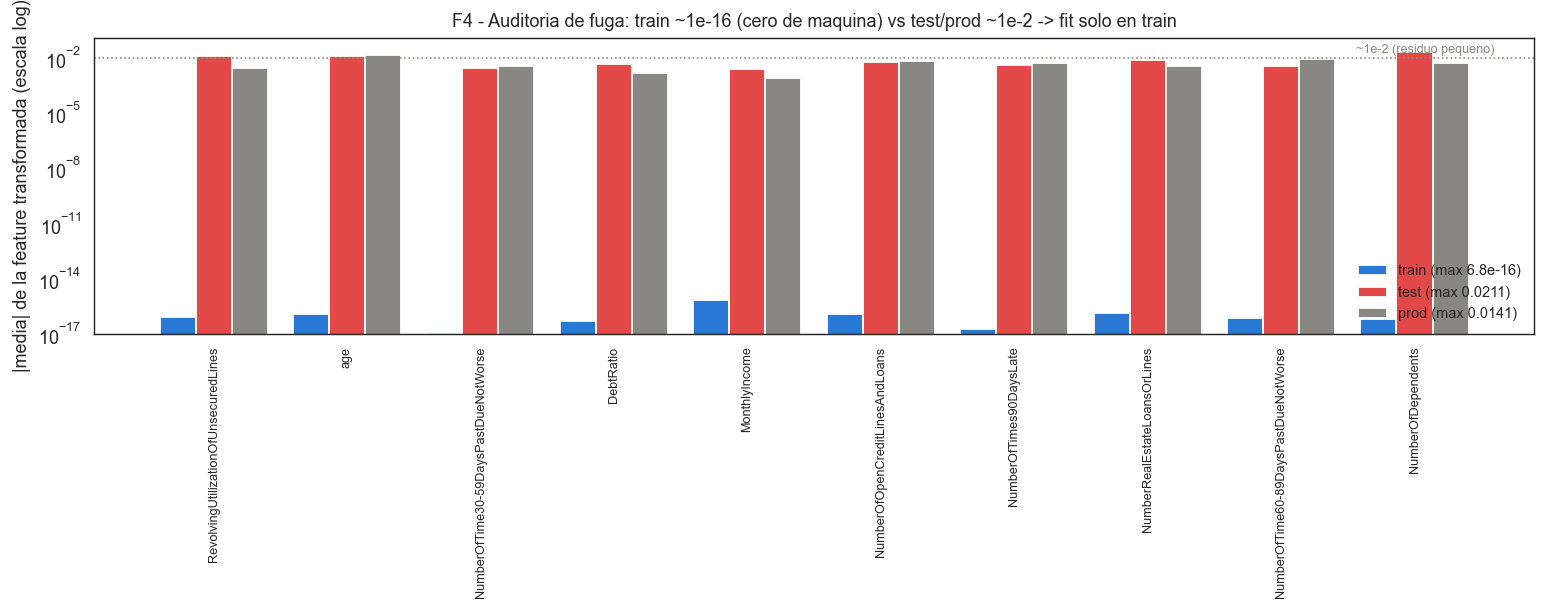

                                                                               descripcion resultado
assert                                                                                              
A                               recarga joblib reproduce transform(test) identico (atol=0)        OK
A                       pipe2 es PreprocesadorCredito fiteado (escalar/recalc/winsor=True)        OK
A               train.parquet[12 features] == transform fresco del pipe recargado (atol=0)        OK
B                                              columnas train==test==prod (features+flags)        OK
B                                       dtypes: 10 float64 + 2 int8, iguales train vs prod        OK
C                                                   sin NaN en features de train/test/prod        OK
D                                       prod=45000 ; train+test=105000 ; test==len(X_test)        OK
E                               transform por lote == fila-a-fila (atol=1e-12) -> apatrida 

In [11]:
# 6.1 Bateria de verificacion A-I (DEMOSTRAR, no afirmar) + F4 (auditoria de fuga).
resultados = []
def _check(letra, descripcion, cond):
    assert cond, f"FALLO {letra}: {descripcion}"
    resultados.append({"assert": letra, "descripcion": descripcion, "resultado": "OK"})

COLS_SALIDA = FEATURES + FLAGS

# --- A. Reproducibilidad de la serializacion ---
pipe2 = joblib.load("results/models/preprocessing_pipeline.joblib")
_check("A", "recarga joblib reproduce transform(test) identico (atol=0)",
       np.allclose(pipe.transform(X_test)[FEATURES].to_numpy(),
                   pipe2.transform(X_test)[FEATURES].to_numpy(), atol=0))
_check("A", "pipe2 es PreprocesadorCredito fiteado (escalar/recalc/winsor=True)",
       isinstance(pipe2, PreprocesadorCredito) and pipe2.escalar and
       pipe2.recalcular_debtratio and pipe2.winsorizar and hasattr(pipe2, "scaler_"))
# El artefacto EN DISCO == lo que produce el pipeline recargado (12 features, atol=0).
_check("A", "train.parquet[12 features] == transform fresco del pipe recargado (atol=0)",
       np.array_equal(pd.read_parquet("data/processed/train.parquet")[COLS_SALIDA].to_numpy(),
                      pipe2.transform(X_train)[COLS_SALIDA].to_numpy()))

# --- B. Igualdad de esquema y dtypes ---
_check("B", "columnas train==test==prod (features+flags)",
       list(train_out.columns) == COLS_SALIDA and list(test_out.columns) == COLS_SALIDA
       and list(prod_out.columns) == COLS_SALIDA)
_check("B", "dtypes: 10 float64 + 2 int8, iguales train vs prod",
       all(train_out[c].dtype == np.float64 for c in FEATURES) and
       all(train_out[c].dtype == np.int8 for c in FLAGS) and
       (train_out.dtypes == prod_out.dtypes).all())

# --- C. Sin NaN inesperado en features (target excluido) ---
_check("C", "sin NaN en features de train/test/prod",
       train_out[FEATURES].isna().sum().sum() == 0 and
       test_out[FEATURES].isna().sum().sum() == 0 and
       prod_out[FEATURES].isna().sum().sum() == 0)

# --- D. Conteo de filas ---
_check("D", "prod=45000 ; train+test=105000 ; test==len(X_test)",
       len(prod_out) == 45000 and len(train_out) + len(test_out) == 105000
       and len(test_out) == len(X_test))

# --- E. Apatridia / no fuga por lote (K=100 filas de prod) ---
idx_k = X_prod.index[:100]
batch = pipe.transform(X_prod.loc[idx_k])
uno_a_uno = pd.concat([pipe.transform(X_prod.loc[[i]]) for i in idx_k])
_check("E", "transform por lote == fila-a-fila (atol=1e-12) -> apatrida",
       np.allclose(batch[FEATURES].to_numpy(), uno_a_uno[FEATURES].to_numpy(), atol=1e-12)
       and (batch[FLAGS].to_numpy() == uno_a_uno[FLAGS].to_numpy()).all())

# --- F. Fit SOLO en train: scaler_.mean_ == media train post-log1p ---
pipe_noscale = construir_preprocesador(escalar=False).fit(X_train)
postwinsor_train = pipe_noscale.transform(X_train)[FEATURES].copy()
postlog1p_train = postwinsor_train.copy()
for c in COLS_LOG:
    postlog1p_train[c] = np.log1p(postlog1p_train[c])
media_train_manual = postlog1p_train.mean().to_numpy()
media_abs_train = float(np.abs(train_out[FEATURES].mean().to_numpy()).max())
media_abs_test = float(np.abs(test_out[FEATURES].mean().to_numpy()).max())
media_abs_prod = float(np.abs(prod_out[FEATURES].mean().to_numpy()).max())
_check("F", "scaler_.mean_ == media train post-log1p ; media(train)~0 ; media(test)!=0",
       np.allclose(pipe.scaler_.mean_, media_train_manual, atol=1e-8) and
       np.allclose(train_out[FEATURES].mean().to_numpy(), 0.0, atol=1e-9) and
       not np.allclose(test_out[FEATURES].mean().to_numpy(), 0.0, atol=1e-6))

# --- G. Invarianza a permutacion ---
rng = np.random.default_rng(RANDOM_STATE)
perm = rng.permutation(len(X_prod))
prod_perm = pipe.transform(X_prod.iloc[perm])
_check("G", "transform(prod[perm]) == transform(prod)[perm] (atol=1e-12)",
       np.allclose(prod_perm[FEATURES].to_numpy(), prod_out[FEATURES].to_numpy()[perm], atol=1e-12)
       and (prod_perm[FLAGS].to_numpy() == prod_out[FLAGS].to_numpy()[perm]).all())

# --- H. Robustez a no-vistos (Dependents==20, Revolving==50708) ---
col_rev = "RevolvingUtilizationOfUnsecuredLines"
i_rev = FEATURES.index(col_rev)
cap_rev = pipe.limites_winsor_[col_rev][1]
valor_cap_escalado = (np.log1p(cap_rev) - pipe.scaler_.mean_[i_rev]) / pipe.scaler_.scale_[i_rev]
mask_sobre_cap = X_prod[col_rev].to_numpy() >= cap_rev
max_dep_prod = int(df_prod["NumberOfDependents"].max())
max_rev_prod = float(df_prod[col_rev].max())
max_dep_train = int(df_train["NumberOfDependents"].max())
_check("H", f"prod finito ; Revolving>=cap recortada a cap train ({cap_rev:.4f})",
       np.isfinite(prod_out[FEATURES].to_numpy()).all() and
       np.allclose(prod_out[col_rev].to_numpy()[mask_sobre_cap], valor_cap_escalado, atol=1e-9))

# --- I. Idempotencia del contrato en disco + id_fila_original ---
train_disk = pd.read_parquet("data/processed/train.parquet")
test_disk = pd.read_parquet("data/processed/test.parquet")
prod_disk = pd.read_parquet("data/processed/produccion.parquet")
esquema_train = FEATURES + FLAGS + [TARGET]
esquema_prod = FEATURES + FLAGS + [TARGET, "id_fila_original"]
_check("I", "columnas en disco == esquema declarado (train/test/prod)",
       list(train_disk.columns) == esquema_train and list(test_disk.columns) == esquema_train
       and list(prod_disk.columns) == esquema_prod)
_check("I", "id_fila_original en disco es permutacion exacta de range(45000) ; prod=45000 filas",
       np.array_equal(np.sort(prod_disk["id_fila_original"].to_numpy()), np.arange(45000))
       and len(prod_disk) == 45000)

# --- F4: auditoria de fuga en |media| por feature, eje Y LOGARITMICO ---
# train cae a ~1e-16 (cero de maquina) y test/prod a ~1e-2. En eje lineal las barras de train
# serian invisibles; en log se ven hundidas en 1e-16 y el gap de ~14 ordenes de magnitud frente
# a test/prod (~1e-2) demuestra de un vistazo que el fit uso SOLO train.
medias = pd.DataFrame({
    "train": train_out[FEATURES].mean(),
    "test": test_out[FEATURES].mean(),
    "prod": prod_out[FEATURES].mean(),
})
fig, ax = plt.subplots(figsize=(12, 4.8))
x = np.arange(len(FEATURES)); w = 0.27
eps = 1e-17  # piso para que el log no reciba un 0 exacto
ax.bar(x - w, np.abs(medias["train"]) + eps, w, color=COLOR_TARGET[0],
       label=f"train (max {media_abs_train:.1e})")
ax.bar(x, np.abs(medias["test"]) + eps, w, color=COLOR_TARGET[1],
       label=f"test (max {media_abs_test:.4f})")
ax.bar(x + w, np.abs(medias["prod"]) + eps, w, color=COLOR_MUTED,
       label=f"prod (max {media_abs_prod:.4f})")
ax.set_yscale("log")
ax.set_ylim(bottom=1e-17)
ax.axhline(1e-2, color=COLOR_MUTED, linestyle=":", linewidth=0.9)
ax.text(len(FEATURES) - 0.4, 1.3e-2, "~1e-2 (residuo pequeno)", ha="right", va="bottom",
        fontsize=7, color=COLOR_MUTED)
ax.set_xticks(x); ax.set_xticklabels(FEATURES, rotation=90, fontsize=7)
ax.set_ylabel("|media| de la feature transformada (escala log)")
ax.set_title("F4 - Auditoria de fuga: train ~1e-16 (cero de maquina) vs test/prod ~1e-2 -> fit solo en train",
             fontsize=10)
ax.legend(fontsize=8, frameon=False, loc="lower right")
guardar_figura(fig, "prep_04_auditoria_fuga_medias")

tabla_verif = pd.DataFrame(resultados).set_index("assert")
guardar_tabla(tabla_verif, "prep_06_verificacion_transform")
print(tabla_verif.to_string())
print(f"\nno-vistos en prod (assert H): Revolving max {max_rev_prod:.0f} -> cap {cap_rev:.4f} ; "
      f"Dependents max prod {max_dep_prod} vs train {max_dep_train}")
print(f"\nmedia|features| -> train {media_abs_train:.2e} | test {media_abs_test:.6f} | prod {media_abs_prod:.6f}")
print("\nVERIFICACION OK")


**Hallazgo 6.1:** las verificaciones **A-I** pasan (tabla `prep_06_verificacion_transform`). `transform` es apatrida: procesar 100 filas de prod en lote es identico a fila-a-fila (**E**, atol 1e-12) e invariante a permutacion (**G**). El `fit` uso SOLO train (**F**): `scaler_.mean_` coincide con la media de train post-log1p y la media de las features transformadas es ~0 en train (max |media| **6.83e-16**) pero NO en test (**0.021086**) ni prod (**0.014083**): F4 lo muestra en escala log, con un gap de ~14 ordenes de magnitud entre train (cero de maquina) y test/prod (residuo pequeno) -no hay fuga ni drift. El pipeline es robusto a no-vistos (**H**: Revolving 50708 recortada al cap **1.102904**, todo finito) y la serializacion es reproducible (**A**, atol=0): las 12 features de `train.parquet` EN DISCO coinciden exactamente (atol=0) con un `transform` fresco del pipeline recargado del joblib, demostrando que el artefacto serializado == lo que produce el pipeline. El contrato en disco es idempotente (**I**): `id_fila_original` es permutacion exacta de range(45000) y produccion conserva 45000 filas.

## Conclusiones del preprocesado

Este notebook cierra las cinco decisiones del bloque 1:
- **D-1.1** imputacion (`MonthlyIncome` por tramo de edad + flag MNAR; `NumberOfDependents` moda 0 sin flag; PastDue centinela) - Hallazgo 2.2.
- **D-1.2** outliers (recalculo `DebtRatio`, KS **0.928403 -> 0.167121**, AUC **0.5212 -> 0.5531**; winsor Revolving p99=**1.102904**, DebtRatio p99.9=**9.184215**; colapso del VIF de las PastDue **40.9/71.7/89.6 -> 1.18/1.15/1.17**) - Hallazgos 3.1 y 3.2.
- **D-1.3** `age==0` imputado con la mediana **52.0000** - Hallazgo 3.2.
- **D-1.4** split estratificado `test_size=0.2` - Hallazgo 1.1.
- **D-1.5** log1p (3 vars) + StandardScaler, `escalar=True` serializado - Hallazgo 4.1.

**Contrato entregado a 03-07:** 3 parquet (`train` 84000x13, `test` 21000x13, `produccion` 45000x14 con `id_fila_original`) + `preprocessing_pipeline.joblib`. La aportacion analitica principal (50% de la nota) es el recalculo del `DebtRatio` contaminado, gobernado por un diagnostico falsable (KS antes/despues).

**Balanceo de clases: decision consciente de NO tratarlo aqui.** El desbalance **6.68%** de clase positiva se conserva intacto en train/test: el preprocesado NO aplica SMOTE ni undersampling. Se DELEGA al modelado (03/04) via `class_weight` o ajuste del umbral por coste, porque remuestrear en el preprocesado (a) antes del split seria fuga, y (b) distorsionaria la probabilidad calibrada que 03/04 van a umbralizar por coste, acoplando ademas preprocesado y modelo. Es una decision explicita (parte de D-0.x), no un olvido.

**Avisos heredados por 03/04:**
- NUNCA hacer `astype(int)` sobre el target de produccion (es float64 all-NaN -> `IntCastingNaNError`); "sin target" = sin etiquetas validas, no columna ausente.
- Antes de escribir `cs_produccion1.csv`/`cs_produccion2.csv`, ordenar por `id_fila_original` y verificar permutacion exacta de range(45000).
- Nota informativa (no bloquea el 02): se conservan los duplicados exactos (decision cerrada). El recuento nan-aware de la seccion 1 (celda del split) da **107 filas de test (0.5095%)** con gemela exacta (10 features + target) en train -> el coste de test es ~0.51% optimista (impacto ~0 con costes simetricos).

Siguen **ABIERTAS** D-0.1, D-0.2, D-0.3 (supervisado vs bandit / un modelo con dos umbrales vs dos modelos / familia de modelo), que cierran 03/04. Tarea de entregable (fuera del .ipynb): pasar D-1.1 a CERRADA y anexar D-1.2..D-1.5 como CERRADAS en `docs/DECISIONES.md`.